In [4]:
import gradio as gr

# 두 숫자를 더하는 함수
def add_numbers(a, b):
    return a + b

# 인터페이스 정의
interface = gr.Interface(
fn=add_numbers,
inputs=[gr.Number(label="숫자 1"),
gr.Number(label="숫자 2")],
outputs=gr.Textbox(label="합계")
)
# 실행
interface.launch()
# 종료
interface.close()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Closing server running on port: 7861


In [5]:
# 필요한 라이브러리 임포트
# 사전 설치 : pip install wordcloud
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os

In [7]:
# 텍스트 파일 읽기
with open('./.venv/dataset/history.txt', 'r', encoding='utf-8') as file:
    text = file.read()

In [8]:
# 워드클라우드 설정 및 생성
wordcloud = WordCloud(
    font_path='malgun',  # 한글 폰트 설정 (맑은 고딕)
    background_color='white',
    width=800,
    height=600,
    max_words=200,
    max_font_size=100,
    min_font_size=10,
    random_state=42
).generate(text)

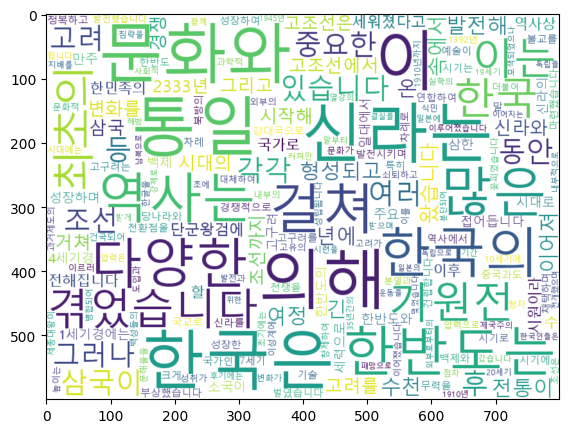

In [ ]:
# 워드 클라우드 이미지 시각화
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [10]:
# gradio설치 전에 이미 설치된 pydantic pydantic-core 제거 : pip uninstall pydantic pydantic-core -y
# gradio 설치 : pip install gradio
# 의존성 에러 발생 시 : pip install --upgrade pydantic
import gradio as gr
from wordcloud import WordCloud
import os

In [11]:
# 워드 클라우드 생성 함수
def generate_wordcloud(file_obj):
    try:
        # 파일이 없는 경우 처리
        if file_obj is None:
            return None

        # Gradio의 파일 객체에서 파일 경로 가져오기
        file_path = file_obj.name

        # 파일 읽기
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()

        # --- 폰트 경로 설정 (중요!) ---
        # 'malgun' 이름만 쓰는 대신, 시스템의 실제 폰트 파일 경로를 지정해야 안정적입니다.
        # 1. 윈도우 (맑은 고딕)
        font_path = "C:/Windows/Fonts/malgun.ttf"

        # 2. 윈도우에 폰트가 없으면 다른 OS 경로 탐색 (예: macOS, Linux)
        if not os.path.exists(font_path):
            # macOS (Apple SD Gothic Neo)
            font_path = "/System/Library/Fonts/AppleSDGothicNeo.ttc"
        if not os.path.exists(font_path):
            # Linux (NanumGothic - 'fonts-nanum' 패키지 설치 필요)
            font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        if not os.path.exists(font_path):
            # 폰트를 못찾으면 None (한글이 깨짐)
            font_path = None
            print("경고: 한글 폰트(맑은 고딕 등)를 찾을 수 없습니다. 한글이 네모로 표시될 수 있습니다.")

        # 워드클라우드 생성
        wordcloud = WordCloud(
            font_path=font_path,  # 위에서 찾은 실제 폰트 경로 사용
            background_color='white',
            width=800,
            height=600,
            max_words=200,
            max_font_size=100,
            min_font_size=10,
            random_state=42
        ).generate(text)

        return wordcloud.to_image()

    except Exception as e:
        print(f"Error: {str(e)}")
        return None

In [12]:
# Gradio 인터페이스 생성
iface = gr.Interface(
    fn=generate_wordcloud,
    inputs=gr.File(label="Upload a .txt file"),
    outputs=gr.Image(type="pil", label="Word Cloud")
)

In [18]:
iface.launch(server_port=7860, share=True, server_name="0.0.0.0")

OSError: Cannot find empty port in range: 7860-7860. You can specify a different port by setting the GRADIO_SERVER_PORT environment variable or passing the `server_port` parameter to `launch()`.

In [17]:
iface.close(server_port=7860, share=False, server_name="0.0.0.0")

TypeError: Blocks.close() got an unexpected keyword argument 'server_port'

In [2]:
# 사전설치 : pip insall ollama
import ollama
import gradio as gr
import base64
from PIL import Image
import io   # io : 메모리 버퍼에 데이터 저장

c:\human\AI_4\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def analyze_image_with_gemma(image):
    """Ollama Gemma 3 4B model을 사용하여 이미지 분석"""
    try:
        # Convert Gradio image to PIL Image
        pil_image = Image.fromarray(image)   # Numpy 배열형태의 이미지를 PIL(이미지처리, 조작) 이미지 객체로 변환

        # Save image to a temporary buffer
        buffer = io.BytesIO()  # 메모리 상에 임시 버퍼를 만들어서 이미지 데이터 저장
        pil_image.save(buffer, format="PNG")

        # Encode image to base64(바이트데이터를 텍스트 형식으로 인코딩)
        encoded_image = base64.b64encode(buffer.getvalue()).decode('utf-8')  # 임시 버퍼에 저장된 이미지 데이터를 바이트(ASCII) 문자열로 가져옴

        # Perform image analysis using Ollama Gemma3
        response = ollama.chat(
            model='gemma3:4b',
            messages=[
                {
                    'role': 'user',
                    'content': '이미지의 내용을 자세히 설명해줘. 무엇이 보이는지, 색상, 구성, 감정 등을 포함해서 분석해줘.',
                    'images': [encoded_image]
                }
            ]
        )

        return response['message']['content']

    except Exception as e:
        return f"이미지 분석 중 오류 발생: {str(e)}"

In [5]:
iface = gr.Interface(
        fn=analyze_image_with_gemma,
        inputs=gr.Image(type="numpy", label="이미지 업로드"),
        outputs=gr.Textbox(label="이미지 분석 결과", lines=20),
        title="Ollama Gemma3 이미지 분석기",
        description="이미지를 업로드하면 Gemma 3 4B 모델이 분석해드립니다."
    )

In [ ]:
iface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


c:\human\AI_4\.venv\lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\human\AI_4\.venv\lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


In [7]:
iface.close()

Closing server running on port: 7860


In [8]:
import gradio as gr
import ollama

In [9]:
def analyze_image(image_path, prompt):
    """
    업로드된 이미지와 프롬프트를 Ollama 모델에 전달하여 결과를 반환하는 함수
    """
    if not image_path:
        return "이미지를 먼저 업로드해주세요."

    try:
        # Ollama API를 호출하여 이미지와 텍스트를 함께 전송
        response = ollama.chat(
            model='gemma4:e2b',
            messages=[
                {
                    'role': 'user',
                    'content': prompt,
                    'images': [image_path] # Gradio에서 전달받은 이미지 파일 경로
                }
            ]
        )
        return response['message']['content']

    except Exception as e:
        error_msg = f"오류가 발생했습니다: {str(e)}\n\n"
        error_msg += "💡 참고: 입력하신 'gemma4:e2b' 모델이 이미지 인식(멀티모달)을 지원하는 비전 모델인지 확인해 주세요. "
        error_msg += "(예: 일반적인 Gemma 텍스트 모델은 이미지를 처리하지 못하며, PaliGemma 같은 모델이 필요합니다.)"
        return error_msg

In [10]:
# Gradio 인터페이스 구성
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# Gemma 이미지 인식기 (gemma4:e2b)")
    gr.Markdown("이미지를 업로드하고 질문을 입력하면 모델이 이미지를 분석하여 답변합니다.")

    with gr.Row():
        with gr.Column():
            # 이미지 입력 컴포넌트 (파일 경로 형태로 전달되도록 설정)
            input_image = gr.Image(type="filepath", label="이미지 업로드")
            input_prompt = gr.Textbox(
                label="질문 (Prompt)",
                value="이 이미지에 대해 자세히 설명해줘.",
                placeholder="이미지에 대해 묻고 싶은 것을 입력하세요."
            )
            submit_btn = gr.Button("분석하기", variant="primary")

        with gr.Column():
            # 결과 출력 컴포넌트
            output_text = gr.Textbox(label="분석 결과", lines=10)

    # 버튼 클릭 시 동작 설정
    submit_btn.click(
        fn=analyze_image,
        inputs=[input_image, input_prompt],
        outputs=output_text
    )

C:\Users\human-17\AppData\Local\Temp\ipykernel_11220\2243521841.py:2: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


In [11]:
demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


c:\human\AI_4\.venv\lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
